# 1D-CNN 베어링 고장 진단과 Data Leakage

**학습 목표:**
- CWRU 베어링 데이터셋을 이해하고 시각화할 수 있다
- 윈도우 슬라이딩과 FFT를 활용하여 진동 신호를 전처리할 수 있다
- 1D-CNN 모델을 학습하고 평가할 수 있다
- **Data Leakage(데이터 누출)**가 무엇이며 왜 위험한지 이해할 수 있다

In [1]:
%matplotlib inline

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import platform
import re
import os

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 설정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 디바이스 설정 (GPU > MPS > CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: mps


## STEP 1: CWRU 데이터 살펴보기

CWRU(Case Western Reserve University) 베어링 데이터셋은 베어링 고장 진단 연구에서 가장 널리 사용되는 데이터입니다.

**데이터 구성:**
- **Normal (정상)**: 결함 없는 정상 베어링
- **Inner Race (내륜 결함)**: 베어링 내부 링에 인위적 결함
- **Outer Race (외륜 결함)**: 베어링 외부 링에 인위적 결함  
- **Ball (볼 결함)**: 베어링 볼에 인위적 결함

각 결함에는 7mil, 14mil, 21mil 크기의 결함이 있으며, 진동 센서로 48kHz 샘플링 레이트로 측정되었습니다.

In [2]:
# 데이터 파일 경로 설정
data_dir = "dataset/"

# 파일 목록과 레이블 정의
file_info = {
    "Time_Normal_1_098.mat": ("Normal", 0),
    "IR007_1_110.mat": ("Inner Race", 1),
    "IR014_1_175.mat": ("Inner Race", 1),
    "IR021_1_214.mat": ("Inner Race", 1),
    "OR007_6_1_136.mat": ("Outer Race", 2),
    "OR014_6_1_202.mat": ("Outer Race", 2),
    "OR021_6_1_239.mat": ("Outer Race", 2),
    "B007_1_123.mat": ("Ball", 3),
    "B014_1_190.mat": ("Ball", 3),
    "B021_1_227.mat": ("Ball", 3),
}

def get_de_signal(filepath):
    """mat 파일에서 DE(Drive End) 진동 신호를 추출하는 함수"""
    mat = loadmat(filepath)
    # 파일명에서 숫자를 추출하여 키 이름 생성 (예: X098_DE_time)
    filename = os.path.basename(filepath)
    # 파일명 끝의 숫자 추출 (예: 098, 110, 175 등)
    number = re.search(r'(\d+)\.mat$', filename).group(1)
    key = f"X{number}_DE_time"
    return mat[key].flatten()

# 하나의 파일을 로드하여 확인
sample_file = os.path.join(data_dir, "Time_Normal_1_098.mat")
signal = get_de_signal(sample_file)
print(f"신호 길이: {len(signal)} 샘플")
print(f"샘플링 레이트: 48,000 Hz")
print(f"측정 시간: {len(signal)/48000:.2f} 초")

신호 길이: 483903 샘플
샘플링 레이트: 48,000 Hz
측정 시간: 10.08 초


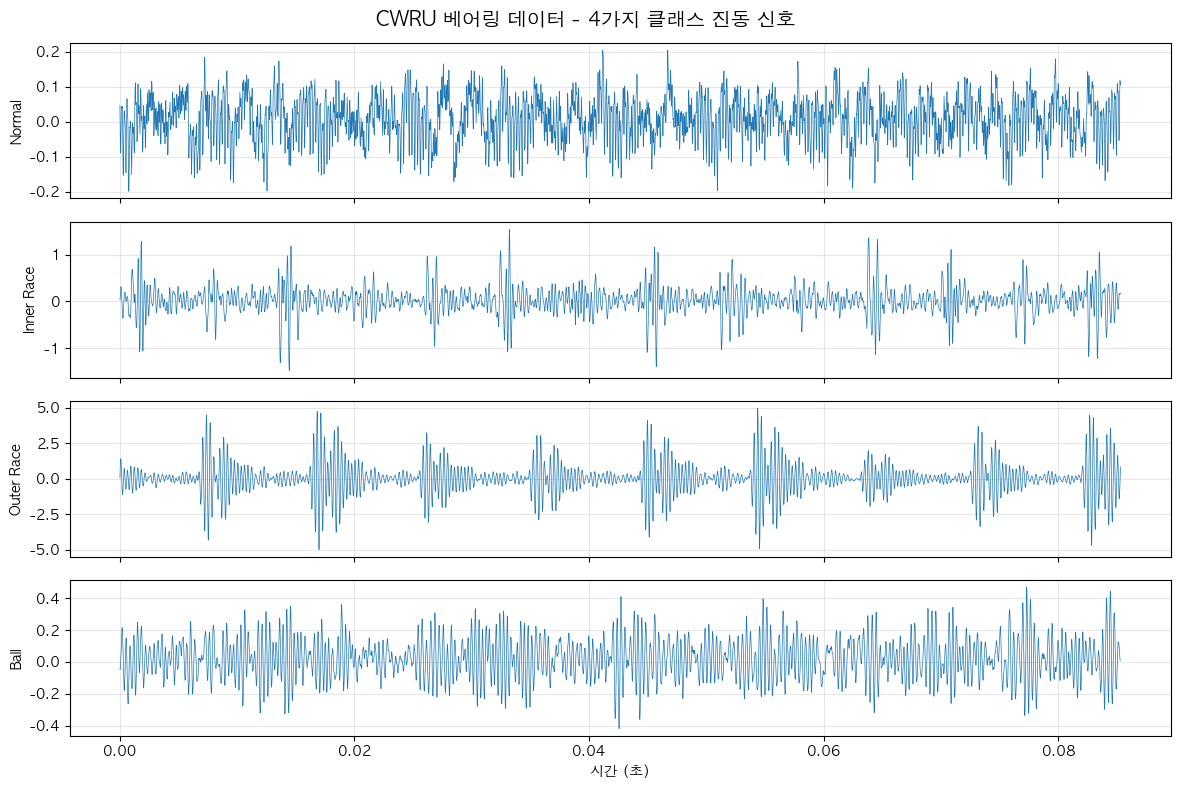

In [3]:
# 4가지 클래스의 시간 영역 신호를 시각화
representative_files = {
    "Normal": "Time_Normal_1_098.mat",
    "Inner Race": "IR007_1_110.mat",
    "Outer Race": "OR007_6_1_136.mat",
    "Ball": "B007_1_123.mat",
}

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for i, (label, fname) in enumerate(representative_files.items()):
    sig = get_de_signal(os.path.join(data_dir, fname))
    # 처음 4096 샘플만 표시 (약 0.085초)
    t = np.arange(4096) / 48000
    axes[i].plot(t, sig[:4096], linewidth=0.5)
    axes[i].set_ylabel(label)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("시간 (초)")
fig.suptitle("CWRU 베어링 데이터 - 4가지 클래스 진동 신호", fontsize=14)
plt.tight_layout()
plt.show()

## STEP 2: 윈도우 슬라이딩 + FFT

### 윈도우 슬라이딩이란?

긴 진동 신호를 일정한 크기의 "윈도우"로 잘라서 여러 개의 샘플을 만드는 방법입니다.

- **윈도우 크기 (window_size)**: 2048 샘플 (약 0.043초)
- **이동 간격 (step)**: 1024 샘플 (50% 겹침)

```
신호: |==========================================================|
윈도우1: |--------|
윈도우2:     |--------|
윈도우3:         |--------|
              (50% 겹침)
```

### FFT (Fast Fourier Transform)란?

시간 영역 신호를 주파수 영역으로 변환하는 방법입니다.
- 시간 영역: "시간이 지남에 따라 진동이 어떻게 변하는가"
- 주파수 영역: "어떤 주파수의 진동이 얼마나 강한가"

베어링 결함은 특정 주파수에서 특징적인 패턴이 나타나므로, FFT가 고장 진단에 매우 유용합니다.

In [4]:
# 윈도우 슬라이딩 + FFT 함수 정의
WINDOW_SIZE = 2048
STEP = 1024

def sliding_window_fft(signal, window_size=WINDOW_SIZE, step=STEP):
    """신호에 윈도우 슬라이딩을 적용하고 각 윈도우에 FFT를 수행"""
    windows = []
    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        # FFT 적용 (양의 주파수 성분만 사용)
        fft_result = np.abs(np.fft.rfft(window))
        windows.append(fft_result)
    return np.array(windows)

# 전체 데이터에 대해 윈도우 슬라이딩 + FFT 적용
X_all = []
y_all = []

for fname, (class_name, label) in file_info.items():
    filepath = os.path.join(data_dir, fname)
    signal = get_de_signal(filepath)
    fft_windows = sliding_window_fft(signal)
    X_all.append(fft_windows)
    y_all.extend([label] * len(fft_windows))
    print(f"{fname}: {len(fft_windows)}개 윈도우 생성 ({class_name})")

X_all = np.concatenate(X_all, axis=0)
y_all = np.array(y_all)

print(f"\n전체 데이터: X={X_all.shape}, y={y_all.shape}")
print(f"FFT 결과 차원: {X_all.shape[1]} (주파수 빈 수)")

Time_Normal_1_098.mat: 471개 윈도우 생성 (Normal)
IR007_1_110.mat: 473개 윈도우 생성 (Inner Race)
IR014_1_175.mat: 371개 윈도우 생성 (Inner Race)
IR021_1_214.mat: 472개 윈도우 생성 (Inner Race)
OR007_6_1_136.mat: 474개 윈도우 생성 (Outer Race)
OR014_6_1_202.mat: 472개 윈도우 생성 (Outer Race)
OR021_6_1_239.mat: 476개 윈도우 생성 (Outer Race)
B007_1_123.mat: 474개 윈도우 생성 (Ball)
B014_1_190.mat: 473개 윈도우 생성 (Ball)
B021_1_227.mat: 474개 윈도우 생성 (Ball)

전체 데이터: X=(4630, 1025), y=(4630,)
FFT 결과 차원: 1025 (주파수 빈 수)


In [5]:
# 정규화(StandardScaler) 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# train/test 분할 (shuffle=True → Data Leakage 발생!)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all, test_size=0.3, random_state=SEED, shuffle=True
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"\n⚠️ 주의: shuffle=True로 분할했습니다. (나중에 이것이 문제가 됩니다!)")

학습 데이터: (3241, 1025)
테스트 데이터: (1389, 1025)

⚠️ 주의: shuffle=True로 분할했습니다. (나중에 이것이 문제가 됩니다!)


## STEP 3: 1D-CNN 모델 학습

1D-CNN(1차원 합성곱 신경망)은 시계열/주파수 데이터의 패턴을 자동으로 학습하는 딥러닝 모델입니다.

**모델 구조:**
1. Conv1D(1→16) + ReLU + MaxPool → 주파수 패턴 추출
2. Conv1D(16→32) + ReLU + MaxPool → 더 복잡한 패턴 추출
3. Flatten → FC(64) → FC(4) → 4개 클래스로 분류

In [6]:
# 1D-CNN 모델 정의
class CNN1D(nn.Module):
    def __init__(self, input_size=1025):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        # input_size → pool → pool: input_size // 4
        self.fc1 = nn.Linear(32 * (input_size // 4), 64)
        self.fc2 = nn.Linear(64, 4)
    
    def forward(self, x):
        # x: (batch, 1, input_size)
        x = self.pool(self.relu(self.conv1(x)))   # (batch, 16, input_size//2)
        x = self.pool(self.relu(self.conv2(x)))   # (batch, 32, input_size//4)
        x = x.flatten(1)                           # (batch, 32 * input_size//4)
        x = self.relu(self.fc1(x))                # (batch, 64)
        x = self.fc2(x)                           # (batch, 4)
        return x

# 모델 학습 함수
def train_model(X_train, y_train, input_size, epochs=10, lr=1e-3, batch_size=32):
    """CNN 모델을 학습하고 학습 손실을 반환"""
    # 데이터를 PyTorch 텐서로 변환
    X_tensor = torch.FloatTensor(X_train).unsqueeze(1)  # (N, 1, features)
    y_tensor = torch.LongTensor(y_train)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # 모델 초기화
    torch.manual_seed(SEED)
    model = CNN1D(input_size=input_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # 학습 루프
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs} - Loss: {avg_loss:.4f}")
    
    return model, losses

🔴 [Leaky 방법] 모델 학습 시작
  Epoch  1/10 - Loss: 0.2502
  Epoch  2/10 - Loss: 0.0215
  Epoch  3/10 - Loss: 0.0059
  Epoch  4/10 - Loss: 0.0044
  Epoch  5/10 - Loss: 0.0015
  Epoch  6/10 - Loss: 0.0011
  Epoch  7/10 - Loss: 0.0003
  Epoch  8/10 - Loss: 0.0002
  Epoch  9/10 - Loss: 0.0002
  Epoch 10/10 - Loss: 0.0002


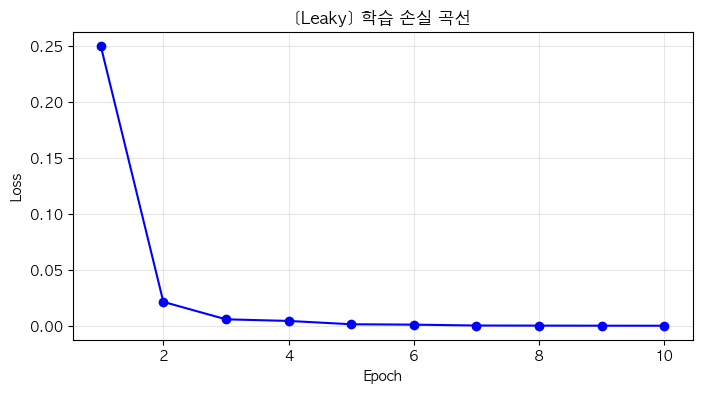

In [7]:
# Leaky 방법으로 모델 학습
print("=" * 50)
print("🔴 [Leaky 방법] 모델 학습 시작")
print("=" * 50)

input_size = X_train.shape[1]
model_leaky, losses_leaky = train_model(X_train, y_train, input_size)

# 학습 손실 곡선
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), losses_leaky, 'b-o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("[Leaky] 학습 손실 곡선")
plt.grid(True, alpha=0.3)
plt.show()

## STEP 4: 평가 - Accuracy, Confusion Matrix, F1-Score

🔴 [Leaky 방법] 테스트 결과

[Leaky] 정확도 (Accuracy): 1.0000 (100.00%)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       155
  Inner Race       1.00      1.00      1.00       405
  Outer Race       1.00      1.00      1.00       428
        Ball       1.00      1.00      1.00       401

    accuracy                           1.00      1389
   macro avg       1.00      1.00      1.00      1389
weighted avg       1.00      1.00      1.00      1389



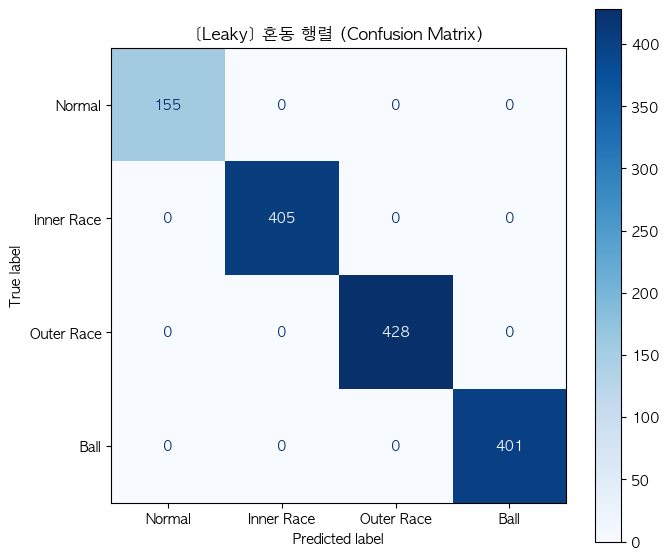

In [8]:
# 모델 평가 함수
def evaluate_model(model, X_test, y_test, title_prefix=""):
    """모델을 평가하고 결과를 시각화"""
    model.eval()
    X_tensor = torch.FloatTensor(X_test).unsqueeze(1).to(device)
    
    with torch.no_grad():
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
    
    # 정확도
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'=' * 50}")
    print(f"{title_prefix} 정확도 (Accuracy): {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'=' * 50}")
    
    # 분류 보고서
    class_names = ["Normal", "Inner Race", "Outer Race", "Ball"]
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")
    
    # 혼동 행렬
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f"{title_prefix} 혼동 행렬 (Confusion Matrix)")
    plt.tight_layout()
    plt.show()
    
    return acc, y_pred

# Leaky 방법 평가
print("🔴 [Leaky 방법] 테스트 결과")
acc_leaky, _ = evaluate_model(model_leaky, X_test, y_test, title_prefix="[Leaky]")

## STEP 5: Data Leakage 문제 설명

### Data Leakage(데이터 누출)란?

위에서 약 99%의 정확도가 나왔습니다. 하지만 이 결과를 믿을 수 있을까요?

### 문제의 원인

우리는 윈도우를 **50% 겹쳐서** 잘랐습니다. 그리고 `shuffle=True`로 랜덤하게 train/test를 나눴습니다.

```
원본 신호:  [...A..|..B..|..C..|..D..|..E..|..F...]
                    ↕50% 겹침
윈도우들:   [A+B] [B+C] [C+D] [D+E] [E+F]

shuffle 후 분할:
  Train: [B+C], [D+E], [A+B]  ← B, D가 포함됨
  Test:  [C+D], [E+F]          ← C, D가 포함됨
                                    ↑ D가 양쪽에!
```

**즉, 학습 데이터와 테스트 데이터에 거의 같은 정보가 들어가 있습니다!**

### 비유로 이해하기

> **시험 문제를 미리 본 것과 같습니다.**
>
> 학생이 시험 전에 문제를 미리 보고 답을 외웠다면, 시험에서 100점을 맞겠지만 실제 실력을 반영하는 것은 아닙니다.
>
> 마찬가지로, 모델이 테스트 데이터와 거의 동일한 데이터를 학습에 사용했다면, 높은 테스트 정확도는 실제 성능을 반영하지 않습니다.

### 실제 현장에서의 위험

공장에 이 모델을 배포했을 때:
- 학습에 사용하지 않은 **완전히 새로운 시간대의 데이터**가 들어옵니다
- Data Leakage로 학습한 모델은 이런 새로운 데이터에서 성능이 크게 떨어질 수 있습니다
- "실험실에서는 99%였는데 현장에서는 70%..." → Data Leakage가 원인일 수 있음

## STEP 6: Data Leakage를 방지한 올바른 방법

**핵심 원칙: 전처리 전에 먼저 분할하라! (Split BEFORE Preprocessing)**

올바른 순서:
1. 원본 신호를 시간 기준으로 앞 70% / 뒤 30%로 나눔
2. 각각에 윈도우 슬라이딩 + FFT 적용
3. 정규화 (학습 데이터 기준으로 fit, 테스트 데이터에 transform만)

이렇게 하면 학습 데이터와 테스트 데이터 사이에 겹치는 구간이 전혀 없습니다.

In [9]:
# 올바른 방법: 원본 신호를 먼저 분할한 후 전처리
X_train_clean = []
y_train_clean = []
X_test_clean = []
y_test_clean = []

for fname, (class_name, label) in file_info.items():
    filepath = os.path.join(data_dir, fname)
    signal = get_de_signal(filepath)
    
    # 원본 신호를 시간 기준으로 분할 (앞 70% = train, 뒤 30% = test)
    split_idx = int(len(signal) * 0.7)
    train_signal = signal[:split_idx]
    test_signal = signal[split_idx:]
    
    # 각각에 윈도우 슬라이딩 + FFT 적용
    train_fft = sliding_window_fft(train_signal)
    test_fft = sliding_window_fft(test_signal)
    
    X_train_clean.append(train_fft)
    y_train_clean.extend([label] * len(train_fft))
    X_test_clean.append(test_fft)
    y_test_clean.extend([label] * len(test_fft))

X_train_clean = np.concatenate(X_train_clean, axis=0)
X_test_clean = np.concatenate(X_test_clean, axis=0)
y_train_clean = np.array(y_train_clean)
y_test_clean = np.array(y_test_clean)

# 정규화 (학습 데이터 기준으로 fit, 테스트에는 transform만)
scaler_clean = StandardScaler()
X_train_clean = scaler_clean.fit_transform(X_train_clean)
X_test_clean = scaler_clean.transform(X_test_clean)

print(f"[Clean] 학습 데이터: {X_train_clean.shape}")
print(f"[Clean] 테스트 데이터: {X_test_clean.shape}")
print(f"\n✅ 학습/테스트 데이터 사이에 겹치는 구간이 없습니다!")

[Clean] 학습 데이터: (3238, 1025)
[Clean] 테스트 데이터: (1378, 1025)

✅ 학습/테스트 데이터 사이에 겹치는 구간이 없습니다!


🟢 [Clean 방법] 모델 학습 시작
  Epoch  1/10 - Loss: 0.2955
  Epoch  2/10 - Loss: 0.0357
  Epoch  3/10 - Loss: 0.0059
  Epoch  4/10 - Loss: 0.0018
  Epoch  5/10 - Loss: 0.0010
  Epoch  6/10 - Loss: 0.0007
  Epoch  7/10 - Loss: 0.0004
  Epoch  8/10 - Loss: 0.0003
  Epoch  9/10 - Loss: 0.0002
  Epoch 10/10 - Loss: 0.0002


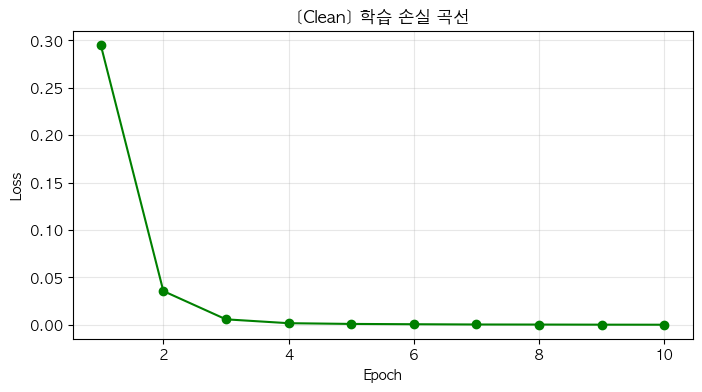

In [10]:
# Clean 방법으로 모델 학습
print("=" * 50)
print("🟢 [Clean 방법] 모델 학습 시작")
print("=" * 50)

input_size_clean = X_train_clean.shape[1]
model_clean, losses_clean = train_model(X_train_clean, y_train_clean, input_size_clean)

# 학습 손실 곡선
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), losses_clean, 'g-o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("[Clean] 학습 손실 곡선")
plt.grid(True, alpha=0.3)
plt.show()

🟢 [Clean 방법] 테스트 결과

[Clean] 정확도 (Accuracy): 1.0000 (100.00%)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       140
  Inner Race       1.00      1.00      1.00       392
  Outer Race       1.00      1.00      1.00       423
        Ball       1.00      1.00      1.00       423

    accuracy                           1.00      1378
   macro avg       1.00      1.00      1.00      1378
weighted avg       1.00      1.00      1.00      1378



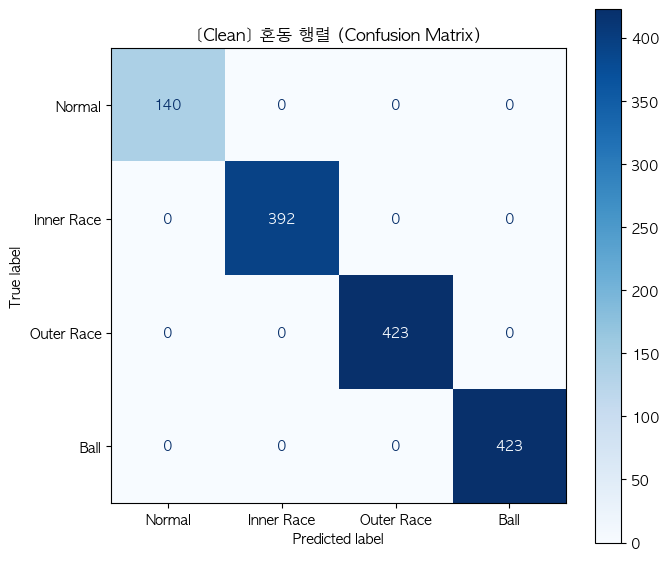

In [11]:
# Clean 방법 평가
print("🟢 [Clean 방법] 테스트 결과")
acc_clean, _ = evaluate_model(model_clean, X_test_clean, y_test_clean, title_prefix="[Clean]")

## STEP 7: 결과 비교 및 정리

📊 결과 비교
  🔴 Leaky 방법 (shuffle 분할):  정확도 = 100.00%
  🟢 Clean 방법 (시간 기준 분할): 정확도 = 100.00%


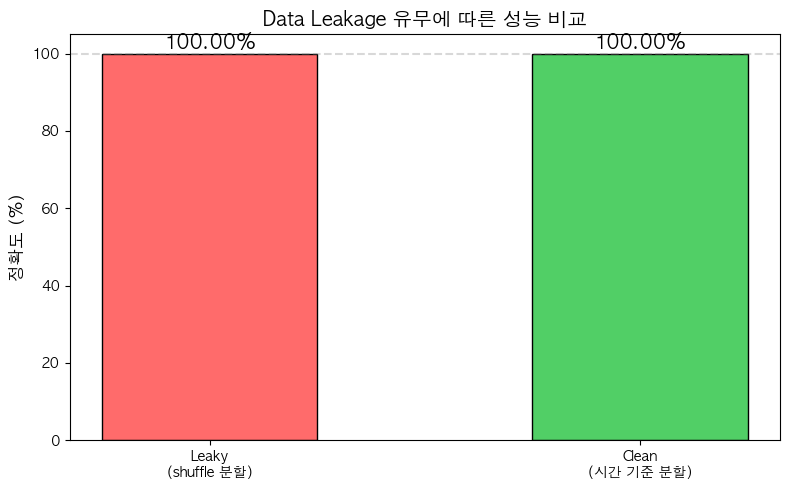

In [12]:
# 결과 비교
print("=" * 60)
print("📊 결과 비교")
print("=" * 60)
print(f"  🔴 Leaky 방법 (shuffle 분할):  정확도 = {acc_leaky*100:.2f}%")
print(f"  🟢 Clean 방법 (시간 기준 분할): 정확도 = {acc_clean*100:.2f}%")
print("=" * 60)

# 비교 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Leaky\n(shuffle 분할)", "Clean\n(시간 기준 분할)"]
accuracies = [acc_leaky * 100, acc_clean * 100]
colors = ['#ff6b6b', '#51cf66']
bars = ax.bar(methods, accuracies, color=colors, width=0.5, edgecolor='black')

# 막대 위에 수치 표시
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel("정확도 (%)", fontsize=12)
ax.set_title("Data Leakage 유무에 따른 성능 비교", fontsize=14)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 핵심 정리

### 이 데이터에서의 결과

CWRU 데이터셋은 실험실에서 통제된 조건에서 측정된 데이터이기 때문에, 시간에 따른 변동이 크지 않습니다. 따라서 Leaky 방법과 Clean 방법의 정확도 차이가 크지 않을 수 있습니다.

### 하지만 실제 현장에서는?

**이 데이터에선 차이가 크지 않을 수 있지만, 실제 현장 데이터처럼 시간에 따라 설비 상태가 변하는 경우에는 Data Leakage가 성능을 크게 부풀릴 수 있습니다.**

실제 시멘트 공장의 베어링 데이터는:
- 온도, 부하, 회전속도가 시간에 따라 변함
- 설비 상태가 점진적으로 악화됨
- 계절, 생산량에 따라 운전 조건이 달라짐

이런 상황에서 Data Leakage가 있으면:
- 실험실 성능: 99% → 현장 성능: 70~80%
- "모델이 왜 현장에서 안 되지?" 의 원인

### 기억할 원칙

| 항목 | 잘못된 방법 | 올바른 방법 |
|------|-------------|-------------|
| 순서 | 전처리 → 분할 | **분할 → 전처리** |
| 분할 | shuffle로 랜덤 | **시간 순서 유지** |
| 정규화 | 전체 데이터로 fit | **학습 데이터만으로 fit** |

> **"항상 분할을 먼저 하고, 그 다음에 전처리하라!"**